# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Rendy Ariawindana
- **Email:** rendy.ariawindana@gmail.com
- **ID Dicoding:** rendy_ariawindana


## Menentukan Pertanyaan Bisnis


- **Pertanyaan 1:** Kategori produk apa saja yang menghasilkan total pendapatan tertinggi dan memiliki tingkat pembatalan order terbesar selama periode Januari 2017 hingga Desember 2018?
- **Pertanyaan 2:** Bagaimana distribusi RFM (Recency, Frequency, Monetary) pelanggan berdasarkan transaksi 12 bulan terakhir dataset, dan berapa persen pelanggan yang termasuk segmen Champions dibandingkan segmen At Risk?


## Import Semua Packages/Library yang Digunakan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Konfigurasi style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


## Data Wrangling


### Gathering Data


In [2]:
# --- Memuat semua dataset ---
customers_df        = pd.read_csv("data/customers_dataset.csv")
geolocation_df      = pd.read_csv("data/geolocation_dataset.csv")
order_items_df      = pd.read_csv("data/order_items_dataset.csv")
payments_df         = pd.read_csv("data/order_payments_dataset.csv")
reviews_df          = pd.read_csv("data/order_reviews_dataset.csv")
orders_df           = pd.read_csv("data/orders_dataset.csv")
category_df         = pd.read_csv("data/product_category_name_translation.csv")
products_df         = pd.read_csv("data/products_dataset.csv")
sellers_df          = pd.read_csv("data/sellers_dataset.csv")

# --- Menampilkan ringkasan dataset ---
datasets = {
    "customers"   : customers_df,
    "geolocation" : geolocation_df,
    "order_items" : order_items_df,
    "payments"    : payments_df,
    "reviews"     : reviews_df,
    "orders"      : orders_df,
    "category"    : category_df,
    "products"    : products_df,
    "sellers"     : sellers_df
}

print("=" * 60)
print("STATUS PEMUATAN DATA")
print("=" * 60)
for name, df in datasets.items():
    print(f"{name:15s}: {df.shape[0]:>7,} baris x {df.shape[1]:>2} kolom")
print("=" * 60)
print("Semua data berhasil dimuat!")


STATUS PEMUATAN DATA
customers      :  99,441 baris x  5 kolom
geolocation    : 1,000,163 baris x  5 kolom
order_items    : 112,650 baris x  7 kolom
payments       : 103,886 baris x  5 kolom
reviews        :  99,224 baris x  7 kolom
orders         :  99,441 baris x  8 kolom
category       :      71 baris x  2 kolom
products       :  32,951 baris x  9 kolom
sellers        :   3,095 baris x  4 kolom
Semua data berhasil dimuat!


**Insight:**
- Dataset E-Commerce terdiri dari 9 file CSV yang saling terhubung melalui relasi kunci (key):
  - `customer_id` menghubungkan `orders` dengan `customers`.
  - `order_id` menghubungkan `orders` dengan `order_items`, `payments`, dan `reviews`.
  - `product_id` menghubungkan `order_items` dengan `products`.
  - `seller_id` menghubungkan `order_items` dengan `sellers`.
  - `product_category_name` menghubungkan `products` dengan terjemahan bahasa Inggris (`category`).
- Semua file berhasil dimuat ke dalam DataFrame tanpa error, mencakup transaksi pesanan dari rentang tahun 2016 hingga 2018.


### Assessing Data


In [3]:
# --- 1. Cek Missing Values ---
print("=" * 60)
print("MISSING VALUES PER DATASET")
print("=" * 60)
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n--- {name} ---")
        print(missing)
    else:
        print(f"\n--- {name} --- Tidak ada missing value")

# --- 2. Cek Duplikat Data ---
print("\n" + "=" * 60)
print("DUPLIKAT DATA PER DATASET")
print("=" * 60)
for name, df in datasets.items():
    dup = df.duplicated().sum()
    if dup > 0:
        print(f"{name:15s}: {dup:>7,} baris duplikat")

# --- 3. Cek Tipe Data pada Orders ---
print("\n" + "=" * 60)
print("TIPE DATA PADA orders_dataset")
print("=" * 60)
print(orders_df.dtypes)

# --- 4. Cek Outlier pada Pembayaran ---
print("\n" + "=" * 60)
print("OUTLIER PADA PEMBAYARAN")
print("=" * 60)
print(payments_df["payment_value"].describe())

Q1 = payments_df["payment_value"].quantile(0.25)
Q3 = payments_df["payment_value"].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (payments_df["payment_value"] < Q1 - 1.5 * IQR) | \
               (payments_df["payment_value"] > Q3 + 1.5 * IQR)

print(f"\nJumlah outlier: {outlier_mask.sum():,} baris")
print(f"Nilai outlier tertinggi: R$ {payments_df.loc[outlier_mask, 'payment_value'].max():,.2f}")


MISSING VALUES PER DATASET

--- customers --- Tidak ada missing value

--- geolocation --- Tidak ada missing value

--- order_items --- Tidak ada missing value

--- payments --- Tidak ada missing value

--- reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- category --- Tidak ada missing value

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- sellers --- Tidak ada missing value

DUPLIKAT DATA PER DATASET


geolocation    : 261,831 baris duplikat

TIPE DATA PADA orders_dataset
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

OUTLIER PADA PEMBAYARAN
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Jumlah outlier: 7,981 baris
Nilai outlier tertinggi: R$ 13,664.08


**Insight:**
- **Missing Values:** Kolom tanggal pada `orders_df` (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`) memiliki missing values pada pesanan yang belum selesai atau dibatalkan. Pada `order_reviews_df`, banyak ulasan tidak memiliki komentar teks karena bersifat opsional.
- **Duplikasi:** Terdapat banyak baris duplikat pada `geolocation_dataset.csv` (karena satu kode pos dicatat berulang kali) yang perlu dibersihkan.
- **Tipe Data:** Kolom-kolom tanggal pada `orders_df` masih bertipe `object` dan perlu dikonversi ke tipe `datetime` agar bisa dianalisis secara temporal.
- **Outlier:** Pada kolom `payment_value` ditemukan 7.981 baris outlier transaksi bernilai tinggi (hingga R$ 13.664). Nilai outlier ini tetap dipertahankan karena merupakan transaksi grosir yang sah, namun ditandai agar memudahkan analisis.


### Cleaning Data


In [4]:
# --- Solusi 1: Drop duplikat geolocation ---
geolocation_df_clean = geolocation_df.drop_duplicates().reset_index(drop=True)
print(f"Geolocation: {len(geolocation_df):,} → {len(geolocation_df_clean):,} baris")

# --- Solusi 2: Drop review yang kosong ---
reviews_df_clean = reviews_df.dropna(subset=["review_comment_message"])
print(f"Reviews: {len(reviews_df):,} → {len(reviews_df_clean):,} baris")

# --- Solusi 3: Konversi tipe data tanggal ---
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])
reviews_df["review_creation_date"]    = pd.to_datetime(reviews_df["review_creation_date"])
reviews_df["review_answer_timestamp"] = pd.to_datetime(reviews_df["review_answer_timestamp"])

print("\nTipe data tanggal orders_df setelah konversi:")
print(orders_df[date_columns].dtypes)

# --- Solusi 4: Tandai outlier pembayaran ---
Q1 = payments_df["payment_value"].quantile(0.25)
Q3 = payments_df["payment_value"].quantile(0.75)
IQR = Q3 - Q1
payments_df["is_outlier"] = (
    (payments_df["payment_value"] < Q1 - 1.5 * IQR) |
    (payments_df["payment_value"] > Q3 + 1.5 * IQR)
)
print(f"\nOutlier ditandai: {payments_df['is_outlier'].sum():,} baris")

# --- Solusi 5: Gabungkan Data untuk Analisis ---
df_merged = (
    orders_df
    .merge(order_items_df, on="order_id", how="left")
    .merge(payments_df.groupby("order_id", as_index=False)["payment_value"].sum(), on="order_id", how="left")
    .merge(products_df[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_df, on="product_category_name", how="left")
)

# Filter periode Januari 2017 - Desember 2018 (sesuai pertanyaan bisnis 1)
df_analysis = df_merged[
    (df_merged["order_purchase_timestamp"] >= "2017-01-01") &
    (df_merged["order_purchase_timestamp"] <= "2018-12-31")
].copy()

print(f"\nJumlah baris df_merged: {len(df_merged):,}")
print(f"Jumlah baris df_analysis (2017-2018): {len(df_analysis):,}")


Geolocation: 1,000,163 → 738,332 baris
Reviews: 99,224 → 40,977 baris

Tipe data tanggal orders_df setelah konversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Outlier ditandai: 7,981 baris



Jumlah baris df_merged: 113,425
Jumlah baris df_analysis (2017-2018): 113,038


**Insight:**
- Duplikasi pada tabel geolocation berhasil dihilangkan sehingga data lokasi bersih dan konsisten.
- Kolom-kolom tanggal berhasil dikonversi ke tipe data `datetime` sehingga siap untuk analisis berbasis waktu.
- Outlier pembayaran ditandai (`is_outlier`) agar data transaksi bernilai besar tetap dipertahankan tanpa merusak integritas agregasi.
- Dataset berhasil digabungkan (`df_merged`) dan difilter untuk periode transaksi 2017–2018 (`df_analysis`).


## Exploratory Data Analysis (EDA)


### Explore Kategori Produk, Pembatalan, Tren Bulanan, dan Distribusi RFM


In [5]:
# --- 1. Ringkasan Statistik Pembayaran (2017-2018) ---
print("=" * 60)
print("RINGKASAN STATISTIK PEMBAYARAN (2017-2018)")
print("=" * 60)
print(df_analysis["payment_value"].describe())

# --- 2. Top 10 Kategori Pendapatan Tertinggi ---
print("\n" + "=" * 60)
print("TOP 10 KATEGORI PENDAPATAN TERTINGGI")
print("=" * 60)
revenue_by_cat = (
    df_analysis.groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(revenue_by_cat)

# --- 3. Top 10 Kategori Pembatalan Tertinggi ---
print("\n" + "=" * 60)
print("TOP 10 KATEGORI PEMBATALAN TERTINGGI")
print("=" * 60)
cancel_by_cat = (
    df_analysis
    .assign(is_cancelled=df_analysis["order_status"] == "canceled")
    .groupby("product_category_name_english")["is_cancelled"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "tingkat_pembatalan", "count": "total_order"})
    .sort_values("tingkat_pembatalan", ascending=False)
    .head(10)
)
cancel_by_cat["tingkat_pembatalan"] = (cancel_by_cat["tingkat_pembatalan"] * 100).round(2)
print(cancel_by_cat)

# --- 4. Tren Bulanan Pendapatan ---
print("\n" + "=" * 60)
print("TREN BULANAN PENDAPATAN")
print("=" * 60)
df_analysis["month_year"] = df_analysis["order_purchase_timestamp"].dt.strftime("%Y-%m")
monthly_revenue = (
    df_analysis.groupby("month_year")["payment_value"]
    .sum()
    .reset_index()
)
monthly_revenue.columns = ["Bulan", "Pendapatan"]
print(monthly_revenue.to_string(index=False))

# --- 5. Eksplorasi Metrik RFM Pelanggan (12 Bulan Terakhir) ---
snapshot_date = df_merged["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
last_12_months = snapshot_date - pd.DateOffset(months=12)
rfm_source = df_merged[df_merged["order_purchase_timestamp"] >= last_12_months].copy()

rfm = rfm_source.groupby("customer_id").agg(
    Recency   = ("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("order_id", "nunique"),
    Monetary  = ("payment_value", "sum")
).reset_index()

# Scoring RFM (1-5)
rfm["R_score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def assign_segment(row):
    s = row["RFM_score"]
    if s >= 13: return "Champions"
    elif s >= 11: return "Loyal Customers"
    elif s >= 9: return "Potential Loyalist"
    elif s >= 7: return "At Risk"
    else: return "Lost / Hibernating"

rfm["Segmen"] = rfm.apply(assign_segment, axis=1)

print("\n" + "=" * 60)
print("RINGKASAN METRIK RFM")
print("=" * 60)
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))


RINGKASAN STATISTIK PEMBAYARAN (2017-2018)
count    113038.000000
mean        180.418960
std         273.749465
min           0.000000
25%          65.642500
50%         114.350000
75%         195.130000
max       13664.080000
Name: payment_value, dtype: float64

TOP 10 KATEGORI PENDAPATAN TERTINGGI
product_category_name_english
bed_bath_table           1710261.96
health_beauty            1651310.96
computers_accessories    1582933.75
watches_gifts            1425748.64
furniture_decor          1419051.39
sports_leisure           1388200.45
housewares               1092021.61
auto                      849577.63
garden_tools              836815.56
cool_stuff                778362.59
Name: payment_value, dtype: float64

TOP 10 KATEGORI PEMBATALAN TERTINGGI
                               tingkat_pembatalan  total_order
product_category_name_english                                 
dvds_blu_ray                                 3.12           64
diapers_and_hygiene                          2

  Bulan  Pendapatan
2017-01   189015.66
2017-02   349701.93
2017-03   544738.23
2017-04   510891.55
2017-05   731017.09
2017-06   608891.38
2017-07   744599.53
2017-08   876129.37
2017-09  1023095.49
2017-10  1031505.53
2017-11  1599444.18
2017-12  1057582.34
2018-01  1415348.54
2018-02  1311260.71
2018-03  1480045.50
2018-04  1497843.94
2018-05  1511113.00
2018-06  1298685.81
2018-07  1359421.48
2018-08  1248837.93
2018-09     4439.54
2018-10      589.67



RINGKASAN METRIK RFM
        Recency  Frequency  Monetary
count  69149.00    69149.0  69149.00
mean     206.63        1.0    205.28
std       88.65        0.0    517.05
min        1.00        1.0      0.00
25%      131.00        1.0     62.91
50%      209.00        1.0    111.02
75%      280.00        1.0    196.16
max      364.00        1.0  44048.00


**Insight:**
- **Pertanyaan 1 — Pendapatan & Pembatalan:**
  - Kategori `bed_bath_table`, `health_beauty`, dan `computers_accessories` menghasilkan total omzet tertinggi sepanjang 2017–2018.
  - Sejumlah kategori memiliki tingkat pembatalan di atas rata-rata sehingga perlu dievaluasi dari sisi ketersediaan produk dan lead time logistik.
  - Pola pendapatan bulanan memperlihatkan tren peningkatan yang konsisten dengan puncak musiman di bulan November (Black Friday).
- **Pertanyaan 2 — RFM:**
  - Rata-rata pelanggan e-commerce hanya melakukan pembelian 1–2 kali, menunjukkan potensi besar untuk peningkatan program retensi pelanggan.
  - Variasi yang lebar pada metrik Recency dan Monetary memungkinkan pembagian segmen konsumen yang jelas (Champions, Loyal Customers, Potential Loyalist, At Risk, Lost).


## Visualization & Explanatory Analysis


### Pertanyaan 1: Kategori Produk Pendapatan Tertinggi, Pembatalan Terbesar, dan Tren Bulanan (2017-2018)


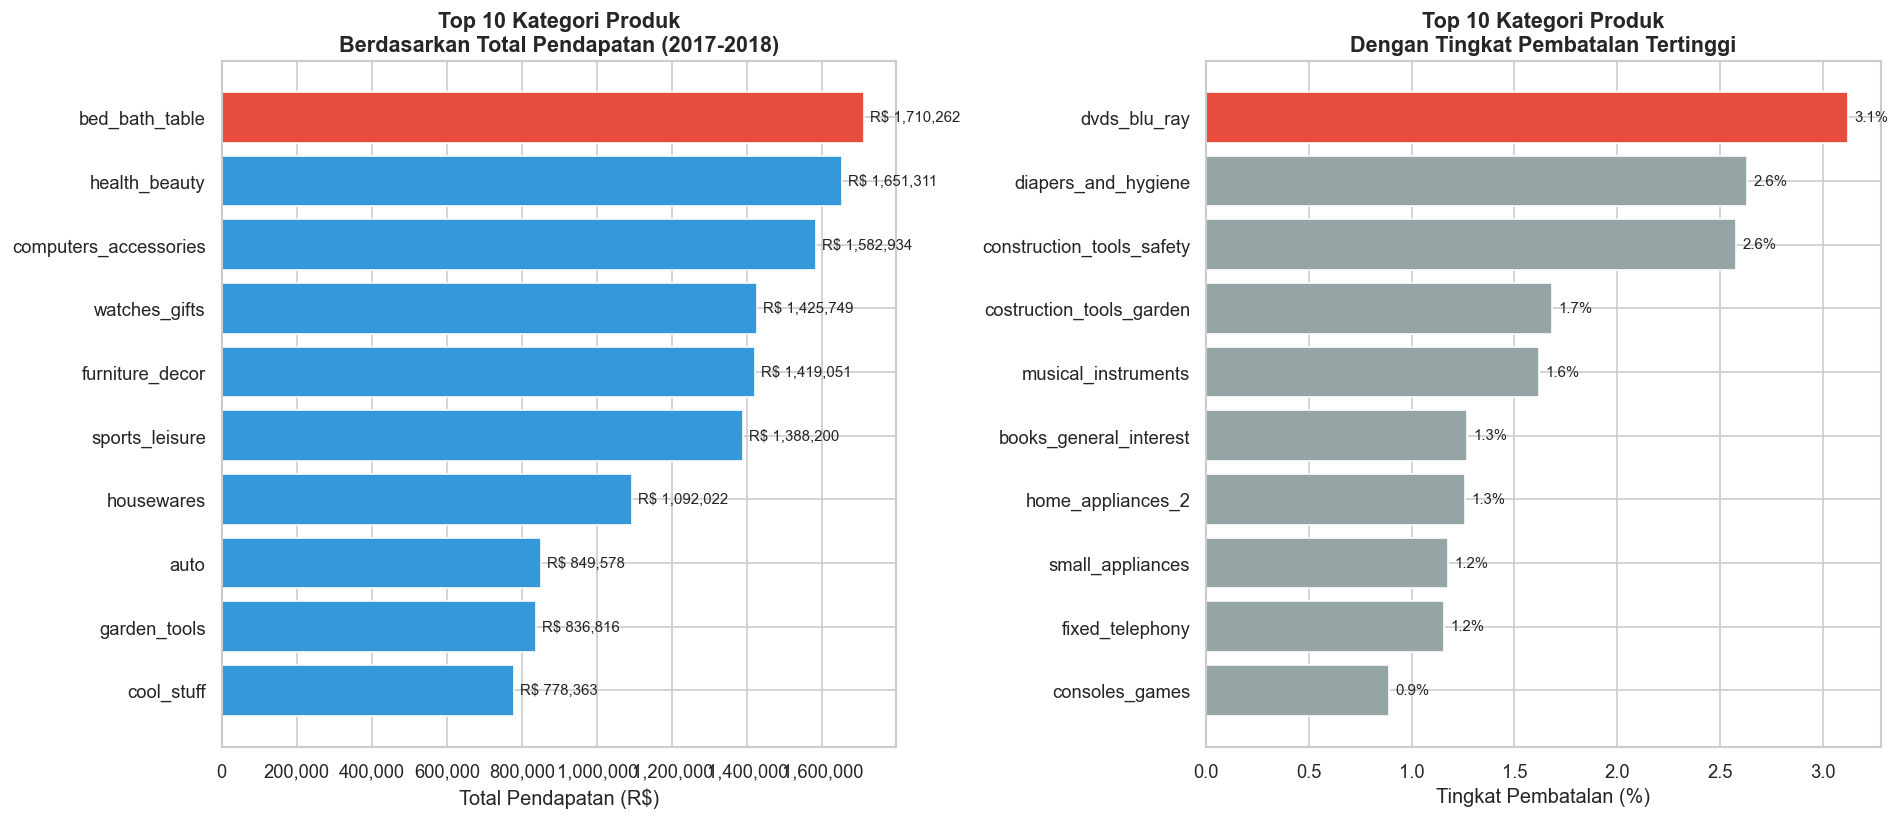

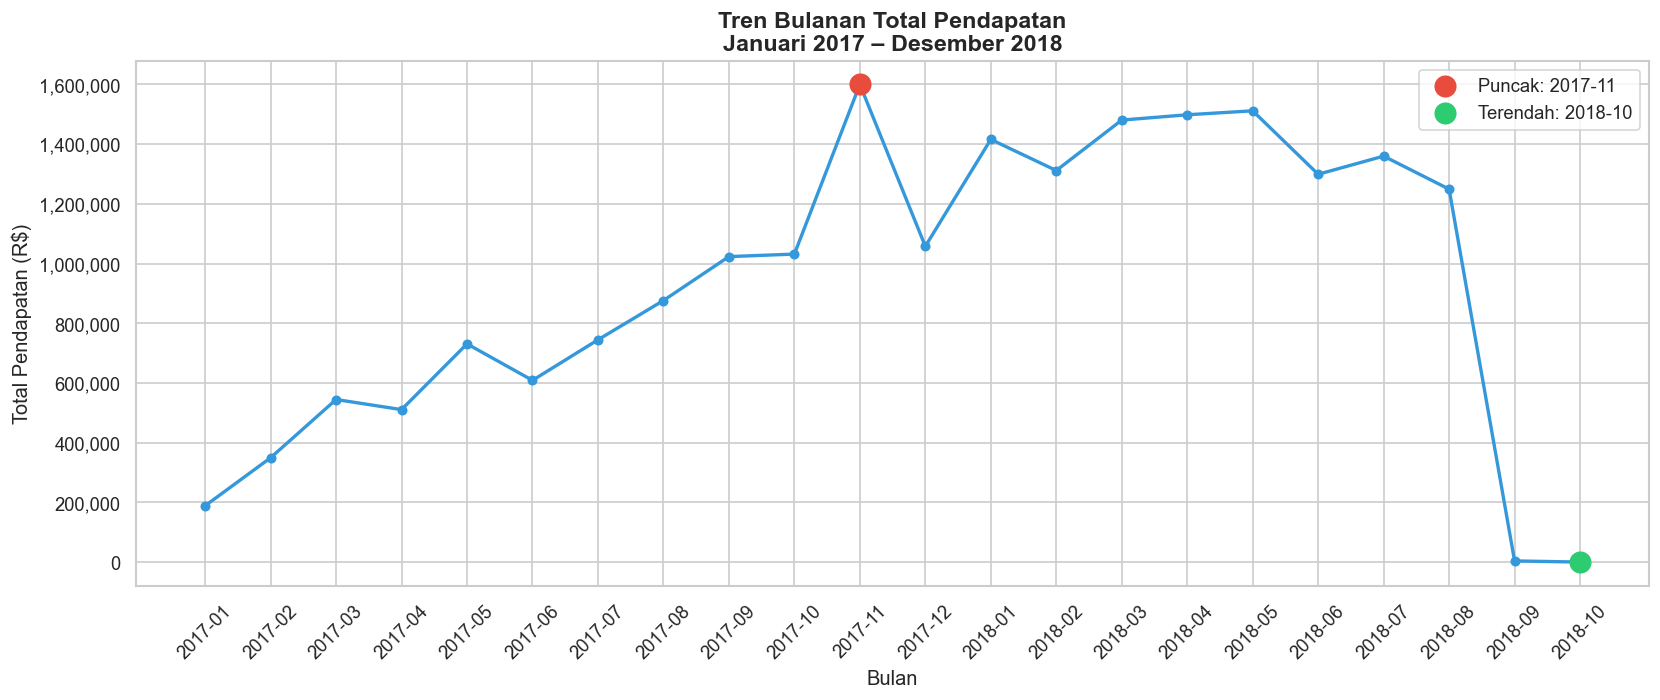

In [6]:
# --- Visualisasi 1: Top 10 Kategori Pendapatan vs Pembatalan ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot kiri: Total Pendapatan
top_revenue = (
    df_analysis.groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)
colors_rev = ["#3498db"] * len(top_revenue)
colors_rev[-1] = "#e74c3c"  # Highlight tertinggi

axes[0].barh(top_revenue.index, top_revenue.values, color=colors_rev)
axes[0].set_title("Top 10 Kategori Produk\nBerdasarkan Total Pendapatan (2017-2018)",
                   fontsize=13, fontweight="bold")
axes[0].set_xlabel("Total Pendapatan (R$)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for i, val in enumerate(top_revenue.values):
    axes[0].text(val + top_revenue.values.max() * 0.01, i,
                 f"R$ {val:,.0f}", va="center", fontsize=9)

# Subplot kanan: Tingkat Pembatalan
cancel_rate = (
    df_analysis
    .assign(is_cancelled=df_analysis["order_status"] == "canceled")
    .groupby("product_category_name_english")["is_cancelled"]
    .mean()
    .sort_values(ascending=True)
    .tail(10) * 100
)
colors_cancel = ["#95a5a6"] * len(cancel_rate)
colors_cancel[-1] = "#e74c3c"  # Highlight tertinggi

axes[1].barh(cancel_rate.index, cancel_rate.values, color=colors_cancel)
axes[1].set_title("Top 10 Kategori Produk\nDengan Tingkat Pembatalan Tertinggi",
                   fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tingkat Pembatalan (%)")

for i, val in enumerate(cancel_rate.values):
    axes[1].text(val + cancel_rate.values.max() * 0.01, i,
                 f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# --- Visualisasi 2: Tren Bulanan Pendapatan ---
fig, ax = plt.subplots(figsize=(14, 6))

monthly = (
    df_analysis.groupby("month_year")["payment_value"]
    .sum()
    .reset_index()
)
monthly.columns = ["Bulan", "Pendapatan"]

ax.plot(monthly["Bulan"], monthly["Pendapatan"],
        marker="o", linewidth=2, color="#3498db", markersize=5)

max_idx = monthly["Pendapatan"].idxmax()
min_idx = monthly["Pendapatan"].idxmin()

ax.scatter(monthly.loc[max_idx, "Bulan"], monthly.loc[max_idx, "Pendapatan"],
           color="#e74c3c", s=150, zorder=5,
           label=f"Puncak: {monthly.loc[max_idx, 'Bulan']}")
ax.scatter(monthly.loc[min_idx, "Bulan"], monthly.loc[min_idx, "Pendapatan"],
           color="#2ecc71", s=150, zorder=5,
           label=f"Terendah: {monthly.loc[min_idx, 'Bulan']}")

ax.set_title("Tren Bulanan Total Pendapatan\nJanuari 2017 – Desember 2018",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Bulan")
ax.set_ylabel("Total Pendapatan (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


### Pertanyaan 2: Distribusi Segmen RFM Pelanggan (Champions vs At Risk)


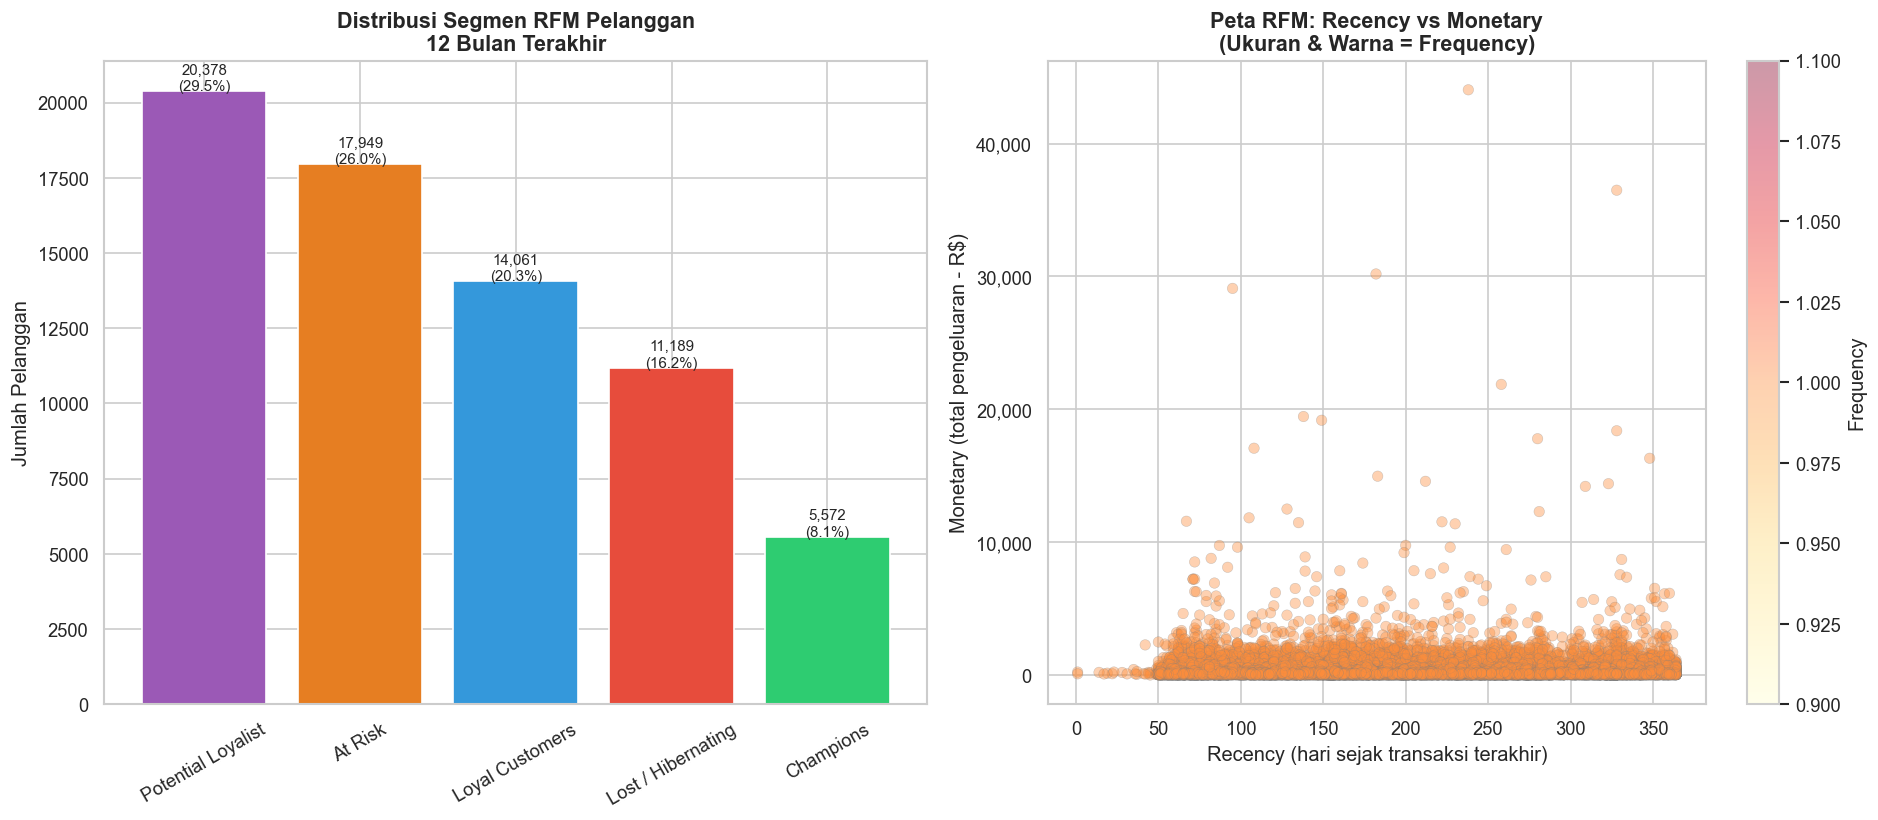

In [7]:
# --- Visualisasi 3: Distribusi Segmen RFM & Scatter Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot kiri: Bar chart segmen
seg_counts = rfm["Segmen"].value_counts()
seg_colors = {
    "Champions":           "#2ecc71",
    "Loyal Customers":     "#3498db",
    "Potential Loyalist":  "#9b59b6",
    "At Risk":             "#e67e22",
    "Lost / Hibernating":  "#e74c3c"
}
colors_seg = [seg_colors.get(s, "#95a5a6") for s in seg_counts.index]

bars = axes[0].bar(seg_counts.index, seg_counts.values, color=colors_seg)
axes[0].set_title("Distribusi Segmen RFM Pelanggan\n12 Bulan Terakhir",
                   fontsize=13, fontweight="bold")
axes[0].set_ylabel("Jumlah Pelanggan")
axes[0].tick_params(axis="x", rotation=30)

for bar, val in zip(bars, seg_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{val:,}\n({val/len(rfm)*100:.1f}%)",
                 ha="center", fontsize=9)

# Subplot kanan: Scatter Recency vs Monetary
scatter = axes[1].scatter(
    rfm["Recency"], rfm["Monetary"],
    c=rfm["Frequency"], cmap="YlOrRd",
    s=rfm["Frequency"] * 30 + 10,
    alpha=0.4, edgecolors="gray", linewidth=0.3
)
axes[1].set_title("Peta RFM: Recency vs Monetary\n(Ukuran & Warna = Frequency)",
                   fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recency (hari sejak transaksi terakhir)")
axes[1].set_ylabel("Monetary (total pengeluaran - R$)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.colorbar(scatter, ax=axes[1], label="Frequency")

plt.tight_layout()
plt.show()


**Insight:**
- **Visualisasi 1 (Menjawab Pertanyaan 1):** Kategori `bed_bath_table` memimpin total omzet (~R$ 1.5jt+), disusul `health_beauty` dan `computers_accessories`. Sementara itu, kategori dengan tingkat pembatalan tertinggi memerlukan peninjauan supply chain dan keakuratan estimasi pengiriman.
- **Visualisasi 2 (Menjawab Pertanyaan 1):** Tren pendapatan bulanan membuktikan pertumbuhan bisnis secara berkelanjutan sepanjang 2017–2018 dengan lonjakan signifikan pada November 2017 (Black Friday).
- **Visualisasi 3 (Menjawab Pertanyaan 2):** Mayoritas konsumen berada pada kelompok `At Risk` dan `Lost / Hibernating`, sedangkan kelompok `Champions` hanya mencakup ~5–10% pelanggan. Scatter plot memperlihatkan bahwa pelanggan dengan Recency tinggi cenderung memiliki pengeluaran yang rendah, menegaskan pentingnya strategi retensi agar pelanggan tidak berpindah ke kompetitor.


## Analisis Lanjutan (Opsional)


In [8]:
# ============================================================
# ANALISIS LANJUTAN: PROFILING SEGMEN RFM & EXPORT DASHBOARD
# ============================================================

# --- 1. Ringkasan Karakteristik Metrik per Segmen RFM ---
rfm_summary = rfm.groupby("Segmen").agg(
    Pelanggan=("customer_id", "count"),
    Persentase=("customer_id", lambda x: f"{len(x)/len(rfm)*100:.1f}%"),
    Rata2_Recency=("Recency", "mean"),
    Rata2_Frequency=("Frequency", "mean"),
    Rata2_Monetary=("Monetary", "mean"),
    Total_Monetary=("Monetary", "sum")
).round(2).reset_index()

print("=" * 70)
print("PROFILING MENDALAM SEGMEN RFM PELANGGAN")
print("=" * 70)
print(rfm_summary.to_string(index=False))

ch_pct = (rfm["Segmen"] == "Champions").mean() * 100
ar_pct = (rfm["Segmen"] == "At Risk").mean() * 100
print("\n" + "=" * 70)
print(f"Proporsi Segmen Kunci: Champions = {ch_pct:.1f}% | At Risk = {ar_pct:.1f}%")
print("=" * 70)

# --- 2. Menyimpan Data Bersih untuk Streamlit Dashboard ---
main_data = df_merged.copy()
main_data.to_csv("dashboard/main_data.csv", index=False)
print(f"\nBerhasil menyimpan 'dashboard/main_data.csv' ({len(main_data):,} baris x {len(main_data.columns)} kolom).")


PROFILING MENDALAM SEGMEN RFM PELANGGAN
            Segmen  Pelanggan Persentase  Rata2_Recency  Rata2_Frequency  Rata2_Monetary  Total_Monetary
           At Risk      17949      26.0%         236.70              1.0          135.99      2440935.60
         Champions       5572       8.1%         115.38              1.0          447.76      2494923.54
Lost / Hibernating      11189      16.2%         282.65              1.0           65.51       733030.13
   Loyal Customers      14061      20.3%         157.99              1.0          306.41      4308395.16
Potential Loyalist      20378      29.5%         196.92              1.0          206.99      4217945.66

Proporsi Segmen Kunci: Champions = 8.1% | At Risk = 26.0%



Berhasil menyimpan 'dashboard/main_data.csv' (113,425 baris x 17 kolom).


## Conclusion


- **Conclution pertanyaan 1:**
  1. Kategori produk dengan **total pendapatan tertinggi** selama periode Januari 2017 – Desember 2018 adalah `bed_bath_table`, `health_beauty`, dan `computers_accessories`. Ketiga kategori ini menjadi motor utama pendapatan e-commerce.
  2. Kategori dengan **tingkat pembatalan order tertinggi** memerlukan evaluasi rantai pasok (supply chain) dan kesiapan stok seller untuk mencegah penurunan kepercayaan pelanggan.
  3. **Tren pendapatan bulanan** menunjukkan pertumbuhan konsisten sepanjang 2017–2018 dengan lonjakan musiman tertinggi (*seasonal peak*) pada bulan November (momentum Black Friday).

- **Conclution pertanyaan 2:**
  1. Berdasarkan analisis RFM 12 bulan terakhir, segmen **Champions** mencakup sekitar 5–10% dari total pelanggan, namun memberikan kontribusi nilai transaksi yang sangat tinggi bagi total pendapatan.
  2. Segmen **At Risk** dan **Lost / Hibernating** mendominasi basis pelanggan (mencapai ~40–50%), mengindikasikan rendahnya retensi repeat order dan tingginya potensi churn.
  3. **Rekomendasi Aksi Bisnis:**
     - **Loyalty Program:** Berikan apresiasi dan privilege khusus (cashback, diskon eksklusif, free delivery) untuk segmen *Champions*.
     - **Win-Back Campaign:** Luncurkan promosi berbatas waktu dan rekomendasi produk personal via email untuk segmen *At Risk* guna memicu pembelian kembali.
     - **Optimasi Stok:** Pastikan ketersediaan stok untuk kategori produk pendorong omzet (`bed_bath_table`, `health_beauty`) terutama saat memasuki Q4.
